# Group 3 BioInformatics Machine Learning Task

## Research question
 	
Machine learning–based identification of morphological features associated with malignancy in breast tumours and derivation of a morphological signature to distinguish malignant from benign cases          

## Importing Libraries

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

## Loading the dataset

In [4]:
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
data = breast_cancer_wisconsin_diagnostic.data

In [7]:
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 
  
# metadata 
print(breast_cancer_wisconsin_diagnostic.metadata) 

print("\n")
 
# variable information 
print(breast_cancer_wisconsin_diagnostic.variables) 

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [10]:
X.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [11]:
y.head()

,Diagnosis
0,M
1,M
2,M
3,M
4,M


## Phase 1: Understanding the basic structure

In [13]:
print("Shape of dataset:", X.shape)

Shape of dataset: (569, 30)


In [14]:
print("\nColumns:\n", X.columns)


Columns:
 Index(['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1',
       'compactness1', 'concavity1', 'concave_points1', 'symmetry1',
       'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2',
       'smoothness2', 'compactness2', 'concavity2', 'concave_points2',
       'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3',
       'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3',
       'symmetry3', 'fractal_dimension3'],
      dtype='object')


In [15]:
print("\nData types:\n", X.dtypes)


Data types:
 radius1               float64
texture1              float64
perimeter1            float64
area1                 float64
smoothness1           float64
compactness1          float64
concavity1            float64
concave_points1       float64
symmetry1             float64
fractal_dimension1    float64
radius2               float64
texture2              float64
perimeter2            float64
area2                 float64
smoothness2           float64
compactness2          float64
concavity2            float64
concave_points2       float64
symmetry2             float64
fractal_dimension2    float64
radius3               float64
texture3              float64
perimeter3            float64
area3                 float64
smoothness3           float64
compactness3          float64
concavity3            float64
concave_points3       float64
symmetry3             float64
fractal_dimension3    float64
dtype: object


In [16]:
X.isnull().sum()
print("\nMissing values in each column:\n", X.isnull().sum())


Missing values in each column:
 radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal_dimension1    0
radius2               0
texture2              0
perimeter2            0
area2                 0
smoothness2           0
compactness2          0
concavity2            0
concave_points2       0
symmetry2             0
fractal_dimension2    0
radius3               0
texture3              0
perimeter3            0
area3                 0
smoothness3           0
compactness3          0
concavity3            0
concave_points3       0
symmetry3             0
fractal_dimension3    0
dtype: int64


In [17]:
X.describe()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [42]:
y.head()

,Diagnosis
0,1
1,1
2,1
3,1
4,1


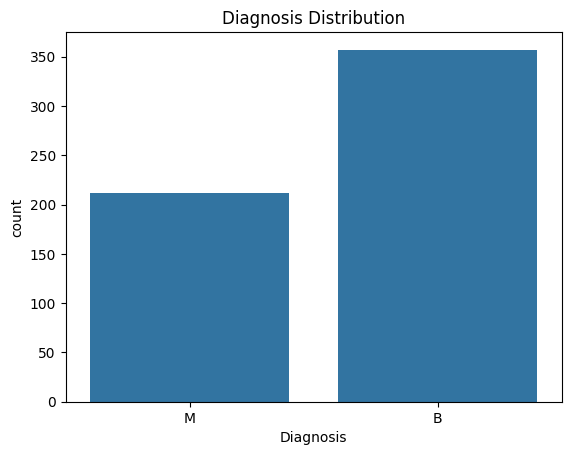

Diagnosis
B    357
M    212
Name: count, dtype: int64

In [20]:
sns.countplot(x=y['Diagnosis'])
plt.title("Diagnosis Distribution")
plt.show()

y['Diagnosis'].value_counts()


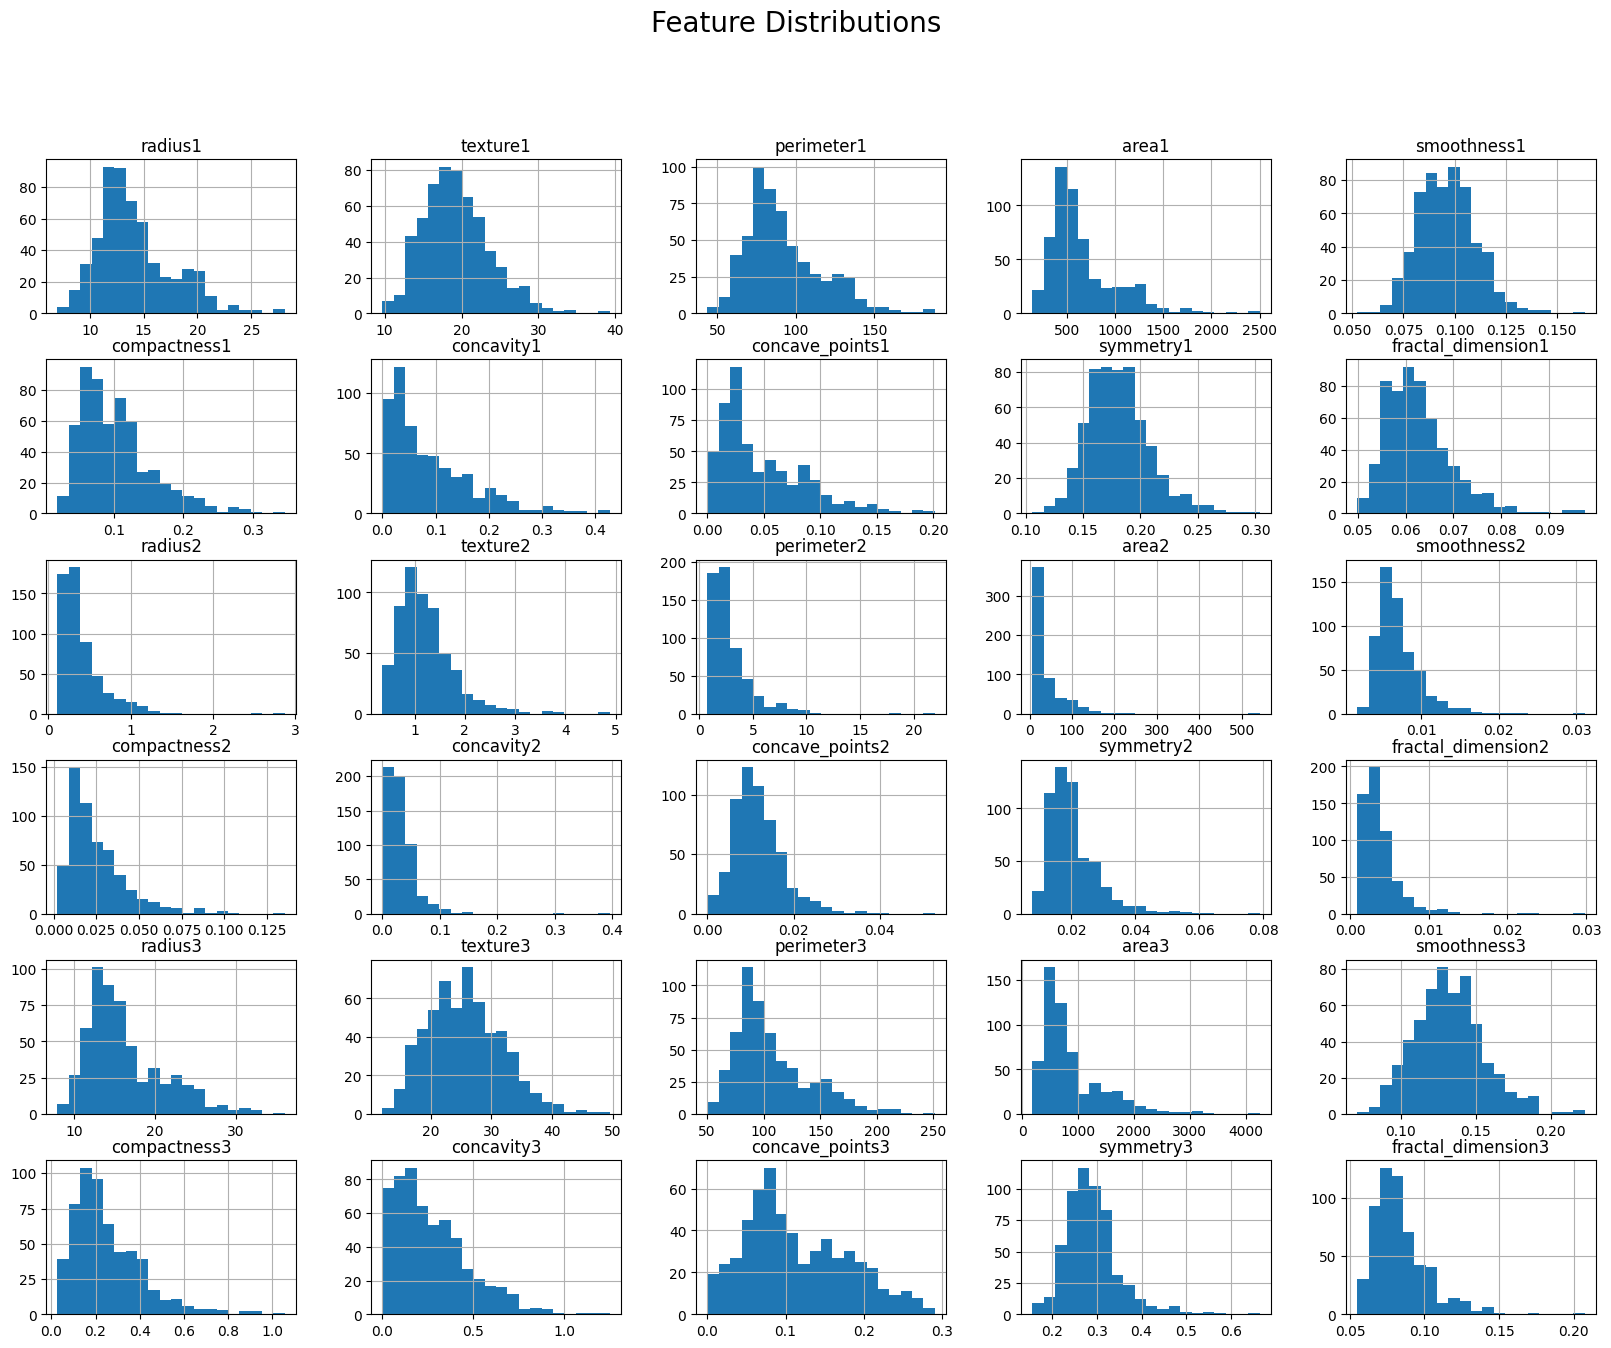

In [22]:
X.hist(bins=20, figsize=(20, 15))
plt.suptitle("Feature Distributions", fontsize=20)
plt.show()


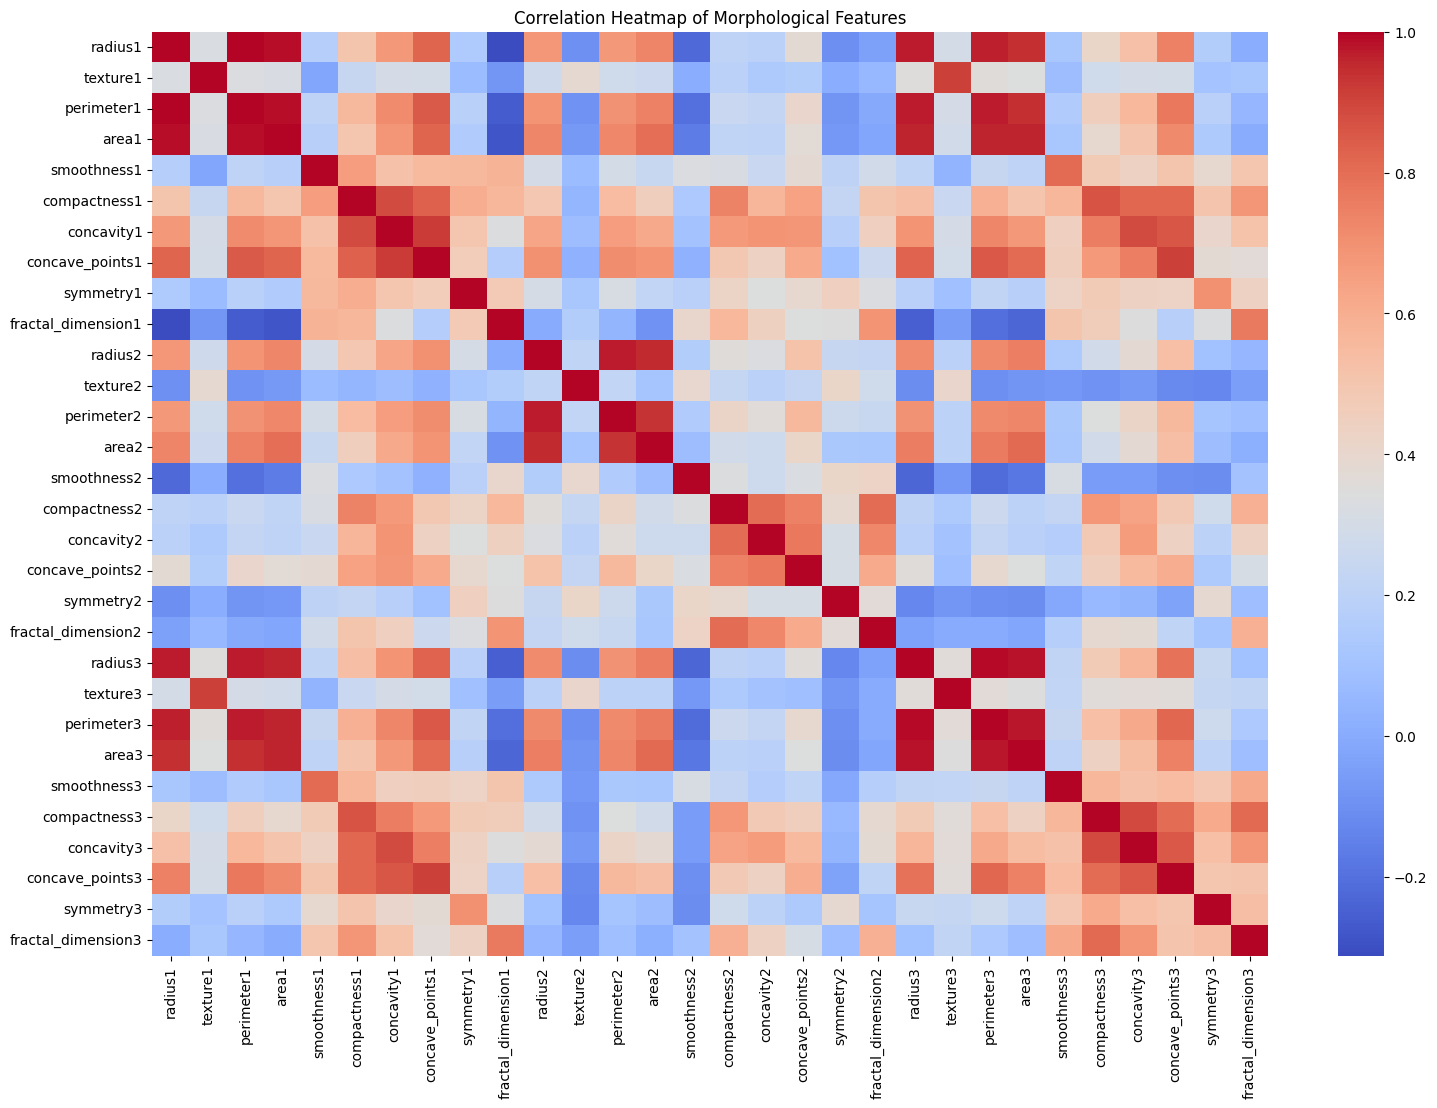

In [23]:
plt.figure(figsize=(18, 12))
sns.heatmap(X.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap of Morphological Features")
plt.show()


### Results of structure analysis

1. The dataset contains 569 samples with 30 columns of features and 1 column for target
2. The target class is Diagnosis with 2 classes M for Malignant and B for Benign
3. The target class is moderately imbalanced with a 63-37% split for B-M
4. Most of the feature columns have right-skewness
5. From the heatmap, we can point out some highgly correlated features:
    - radius_mean ↔ perimeter_mean
    - area_mean ↔ radius_mean
    - concavity_mean ↔ concave_points_mean
    - radius_worst ↔ perimeter_worst
    - compactness_worst ↔ concavity_worst

## Phase 2: Preprocessing

### Encoding the Diagnosis into binary

In [ ]:
y['Diagnosis'] = y['Diagnosis'].map({'M': 1, 'B': 0})
y['Diagnosis'].value_counts()

/var/folders/5r/f45htw414k9ft_42jy1fb_6r0000gn/T/ipykernel_4755/4088882567.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['Diagnosis'] = y['Diagnosis'].map({'M': 1, 'B': 0})


Diagnosis
0    357
1    212
Name: count, dtype: int64

### Scaling

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


### Making the train test split to prepare for later classification

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(398, 30) (171, 30)
(398, 1) (171, 1)


## Phase 3: Clustering Task

We chose K-Means clustering because the dataset consists of continuous numerical morphological features that are well-suited for distance-based clustering. With two natural biological classes (benign vs malignant), K-Means with k=2 allows us to examine whether tumours naturally group based on morphology alone. It is fast, scalable, interpretible, and capable of revealing underlying structure in high-dimensional numeric data. This helps identify morphological signatures associated with malignancy and supports the biological goals of the project.

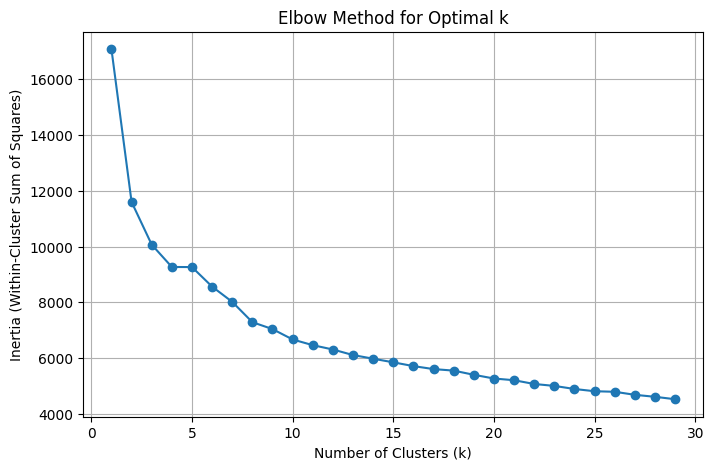

In [36]:
inertia_values = []
cluster_range = range(1, 30)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(cluster_range, inertia_values, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()

The steepness of the graph changes when moving from k=1 to k=2 thus supporting our assumption to use k=2 clusters.

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

In [41]:
# create a clean dataframe combining features, diagnosis and cluster labels
df_clean = X.copy()
df_clean['diagnosis'] = y['Diagnosis']  # use the existing y dataframe
df_clean['cluster'] = cluster_labels

# show diagnosis vs cluster for the first rows
df_clean[['diagnosis', 'cluster']].head(10)


,diagnosis,cluster
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0
5,1,0
6,1,0
7,1,0
8,1,0
9,1,0


In [44]:
y.value_counts()

Diagnosis
0            357
1            212
Name: count, dtype: int64

In [43]:
df_clean['cluster'].value_counts()

cluster
1    381
0    188
Name: count, dtype: int64

In [45]:
comparison_table = pd.crosstab(df_clean['diagnosis'], df_clean['cluster'],
                               rownames=['Actual'], colnames=['Cluster'])
comparison_table


Cluster,0,1
Actual,,
0,13,344
1,175,37


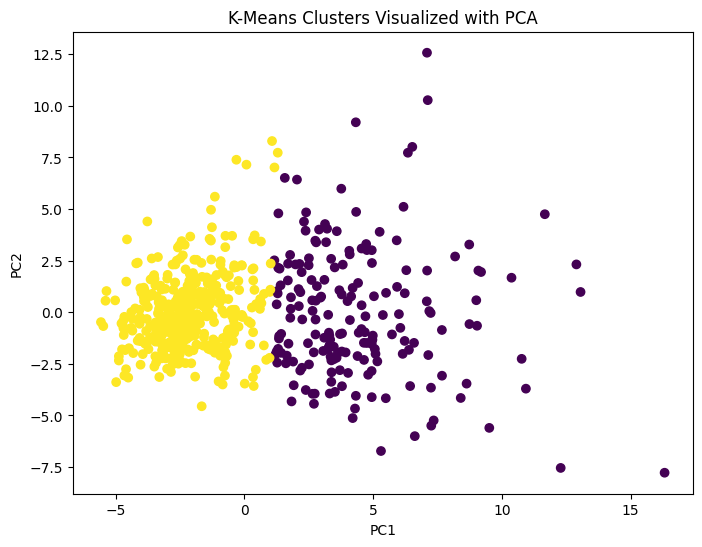

In [46]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(components[:,0], components[:,1], c=cluster_labels, cmap='viridis')
plt.title("K-Means Clusters Visualized with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [47]:
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=X.columns)
centroids


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,0.986498,0.492021,1.018667,0.974797,0.587118,1.014073,1.144922,1.170283,0.603390,0.229274,...,1.052213,0.517057,1.077695,1.013917,0.598044,0.952855,1.051443,1.153288,0.599413,0.613620
1,-0.486776,-0.242782,-0.502649,-0.481002,-0.289706,-0.500382,-0.564949,-0.577462,-0.297736,-0.113133,...,-0.519202,-0.255136,-0.531776,-0.500306,-0.295098,-0.470175,-0.518822,-0.569077,-0.295773,-0.302784


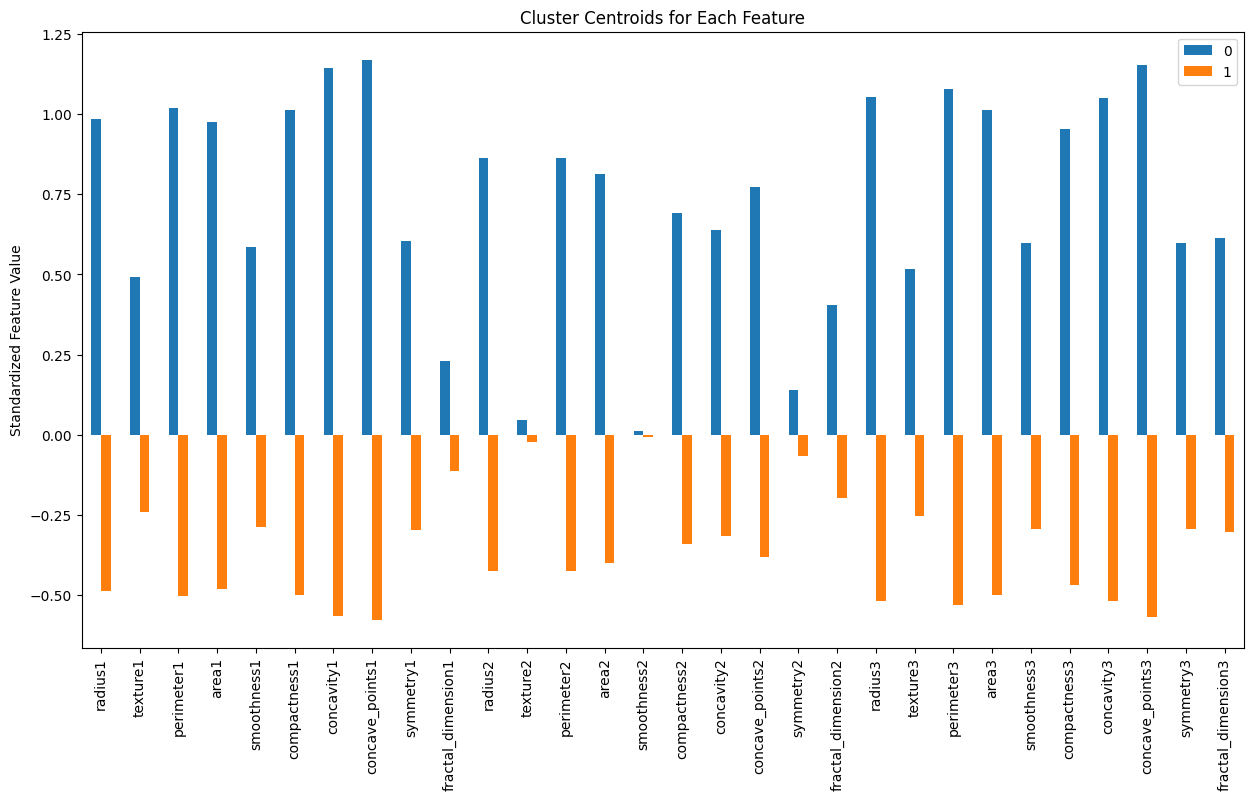

In [48]:
centroids.T.plot(kind='bar', figsize=(15,8))
plt.title("Cluster Centroids for Each Feature")
plt.ylabel("Standardized Feature Value")
plt.xticks(rotation=90)
plt.show()
